# 당뇨병 여부 분류
1. 데이터 로드
2. train / valid / test 데이터 분리
3. 파이프라인 (결측치 처리 & 정규화)
4. Tensor 변환
5. 미니배치 학습 준비
6. 다층 퍼셉트론 모델 준비
7. Optimizer / Scheduler / EarlyStopping 적용하여 학습
8. 학습 시각화
9. 각종 지표 확인
10. Optimizer 여러개 성능 비교
11. K-Fold Cross Validation

- 데이터셋
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

- y : Outcome  
0 -> 당뇨병 음성  
1 -> 당뇨병 양성

In [48]:
# 커널 가상환경에 설치 (== !pip install tqdm)
%pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [49]:
import os         # 운영체제 관련 제어
import random     # 랜덤 시드 고정
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn  # 신경망 구성 및 손실함수
from torch.utils.data import TensorDataset, DataLoader  # Tensor 데이터셋 / 미니배치 로더

import kagglehub  # 캐글 데이터셋 다운로드용
from tqdm.auto import tqdm  # 프로그레스바

from sklearn.model_selection import train_test_split, StratifiedKFold  # 데이터 분리 / K-Fold 검증
from sklearn.pipeline import Pipeline      # 전처리 과정 통합
from sklearn.impute import SimpleImputer   # 결측치 처리
from sklearn.preprocessing import StandardScaler  # 표준화
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)

# 한글 폰트 설정 (Mac은 AppleGothic)
plt.rcParams["font.family"] = "Malgun Gothic"

# 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

In [50]:
SEED = 42  # 랜덤 시드값

random.seed(SEED)        # 파이썬 랜덤 시드 고정
np.random.seed(SEED)     # numpy 랜덤 시드 고정
torch.manual_seed(SEED)  # Pytorch CPU 랜덤 시드 고정

# GPU 가용시
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)  # Pytorch GPU 랜덤 시드 고정

# GPU 가용시 device = "cuda", 아니면 "cpu"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

1. 데이터 로드

In [51]:
data_path = kagglehub.dataset_download("jamaltariqcheema/pima-indians-diabetes-dataset", path="diabetes.csv")

df = pd.read_csv(data_path)

print(df.shape)
df

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76.0,48,180.0,32.9,0.171,63,0
764,2,122,70.0,27,102.5,36.8,0.340,27,0
765,5,121,72.0,23,112.0,26.2,0.245,30,0
766,1,126,60.0,32,169.5,30.1,0.349,47,1


In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [53]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [54]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

|컬럼명|설명|
|---|---|
|Pregnancies|임신 횟수|
|Glucose|포도당 수치|
|BloodPressure|혈압|
|SkinThickness|피부 두께|
|Insulin|인슐린 수치|
|BMI|체질량지수|
|DiabetesPedigreeFunction|당뇨병 가족력 지표|
|Age|나이|
|Outcome|당뇨병 여부|

,count,ratio
Outcome,,
0,500,0.651042
1,268,0.348958


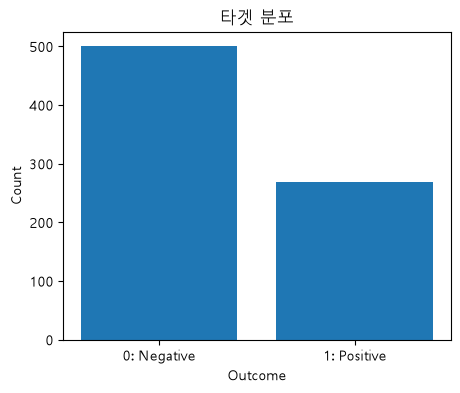

In [55]:
target_counts = df['Outcome'].value_counts().sort_index()  # 클래스별 데이터 갯수
target_ratio = df['Outcome'].value_counts(normalize=True).sort_index()  # 클래스별 비율

# 갯수와 비율을 표로 출력
display(pd.DataFrame({
    "count": target_counts,
    "ratio": target_ratio
}))

plt.figure(figsize=(5, 4))
plt.bar(["0: Negative", "1: Positive"], target_counts.values)  # 클래스별 갯수 막대그래프
plt.title("타겟 분포")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

2. train / valid / test 데이터 분리

In [56]:
X = df.drop(columns='Outcome')
y = df['Outcome']

print(X.shape, y.shape)

(768, 8) (768,)


In [57]:
# test데이터를 8:2 비율로 나눈다 (전역 시드값 설정, y 비율 유지)
X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = SEED,
    stratify = y
)

# 남은 80% 데이터를 8:2 비율로 train / valid 데이터를 나눈다. (전역 시드값 설정, y_train_valid 비율 유지)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid, y_train_valid,
    test_size = 0.2,
    random_state = SEED,
    stratify = y_train_valid
)

print(f"X_train : {X_train.shape}, X_valid : {X_valid.shape}, X_test : {X_test.shape}")
print(f"y_train : {y_train.shape}, y_valid : {y_valid.shape}, y_test : {y_test.shape}")

X_train : (491, 8), X_valid : (123, 8), X_test : (154, 8)
y_train : (491,), y_valid : (123,), y_test : (154,)


In [58]:
preprocess_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy='median')),  # 결측치가 있다면 중앙값 대체
    ("scaler", StandardScaler())  # 평균 0, 표준편차 1 표준화
])

X_train_scaled = preprocess_pipeline.fit_transform(X_train)  # train 데이터는 전처리 기준 학습 / 변환
X_valid_scaled = preprocess_pipeline.transform(X_valid)      # valid 데이터는 학습된 기준으로 변환
X_test_scaled = preprocess_pipeline.transform(X_test)        # test 데이터는 학습된 기준으로 변환

print(X_train_scaled.shape, X_valid_scaled.shape, X_test_scaled.shape)

(491, 8) (123, 8) (154, 8)


4. Tensor 형태로 변환

In [59]:
# 텐서 데이터로 변환 : y 데이터는 모델 학습 및 사용에 적합하도록 2차원 형태로 변환
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_valid_tensor = torch.FloatTensor(X_valid_scaled)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.float32).reshape(-1, 1)  # Series에서 numpy로 데이터 변경 후 Tensor로 변환
y_valid_tensor = torch.tensor(y_valid.to_numpy(), dtype=torch.float32).reshape(-1, 1)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.float32).reshape(-1, 1)

print(f"X_train_tensor : {X_train_tensor.shape}, X_valid_tensor : {X_valid_tensor.shape}, X_test_tensor : {X_test_tensor.shape}")
print(f"y_train_tensor : {y_train_tensor.shape}, y_valid_tensor : {y_valid_tensor.shape}, y_test_tensor : {y_test_tensor.shape}")

X_train_tensor : torch.Size([491, 8]), X_valid_tensor : torch.Size([123, 8]), X_test_tensor : torch.Size([154, 8])
y_train_tensor : torch.Size([491, 1]), y_valid_tensor : torch.Size([123, 1]), y_test_tensor : torch.Size([154, 1])


5. 미니배치 학습 준비

In [60]:
BATCH_SIZE = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
valid_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# DataLoader를 사용해서 미니배치 단위로 데이터를 나눠 학습
train_loader = DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    shuffle = True
)

# 검증 데이터셋과 테스트 데이터셋을 만들기
valid_loader = DataLoader(
    valid_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False
)

test_loader = DataLoader(
    test_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False
)

print(len(train_loader), len(valid_loader), len(test_loader))

16 4 5


6. 다층 퍼셉트론 모델 정의

In [61]:
class DiabetesMLP(nn.Module):

    def __init__(self, input_dim, hidden_dims=(64, 32, 16), dropout=0.2, activation="silu"):
        super().__init__()  # 부모 클래스 초기화

        layers = []  # 신경망 계층을 모두 저장할 리스트
        prev_dim = input_dim  # 이전 계층의 출력 차원

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))   # 배치 정규화 (평균 0, 표준편차 1) : 수치 안정화 -> 학습 안정화

            # 활성화 함수 추가 (비선형성 추가)
            if activation == 'relu':
                layers.append(nn.ReLU())
            elif activation == 'gelu':
                layers.append(nn.GELU())
            elif activation == 'silu':
                layers.append(nn.SiLU())
            else:
                raise ValueError("활성화함수는 relu, gelu, silu 중 하나로 선택해 주세요!")
            
            layers.append(nn.Dropout(dropout))  # 일부 파라미터 생략 (과적합 완화)
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, 1))  # 이진 분류 출력층
        self.net = nn.Sequential(*layers)      # 계층들을 순서대로 연결
    
    def forward(self, x):
        return self.net(x)

In [62]:
input_dim = X_train_tensor.size(-1)  # 입력 특성 개수

model = DiabetesMLP(input_dim = input_dim).to(device)

model

DiabetesMLP(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): SiLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): SiLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): SiLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=16, out_features=1, bias=True)
  )
)

In [63]:
# 양성 클래스 비율이 낮을 때 양성 클래스에 더 큰 가중치를 부여하는 손실함수
num_positive = y_train_tensor.sum()  # 양성 클래스 갯수
num_negative = len(y_train_tensor) - num_positive  # 음성 클래스 갯수
pos_weight = (num_negative / num_positive).to(device)  # 양성 클래스 가중치

print(f"양성 클래스 가중치 : {pos_weight}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)  # 이진 분류 손실 함수 (양성 가중치 부여)

optimizer = torch.optim.AdamW(
    model.parameters(),  # 학습할 모델 파라미터
    lr=0.001,
    weight_decay=1e-4    # 가중치 감쇠 (과적합 완화)
)

# 스케줄러 : 학습률을 조정하여 최대한 학습되도록 만드는 도구
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,      # 학습률 조정할 최적화함수 
    mode = 'min',   # valid_loss가 작아지는 방향
    factor = 0.5,   # 학습률을 절반으로 감소
    patience = 5    # 개선이 5 epochs 동안 없으면 감소
)

양성 클래스 가중치 : 1.871345043182373


In [64]:
# EarlyStopping : 일정 epoch 동안 성능이 좋아지지 않으면 학습을 멈추는 도구
class EarlyStopping:
    def __init__(self, patience=20, min_delta=0.0):
        self.patience = patience    # 개선이 없을때 기다릴 epoch 수
        self.min_delta = min_delta  # 개선으로 인정할 최소 손실 감소량
        self.best_loss = np.inf     # 현재까지 가장 낮은 valid loss
        self.counter = 0            # 개선이 없던 epoch 수
        self.best_state = None      # 가장 성능이 좋은 모델의 가중치
        self.should_stop = False    # 학습 중단 여부 플래그
    
    def step(self, valid_loss, model):
        # 최소 손실 갱신시
        if valid_loss < self.best_loss - self.min_delta:
            self.best_loss = valid_loss
            self.counter = 0

            # 가장 좋은 모델의 가중치 저장
            self.best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
        else:
            self.counter += 1

            # patience 동안 개선이 없을시
            if self.counter >= self.patience:
                self.should_stop = True  # 학습 중단 신호

학습 함수와 검증 함수
- 학습 과정
1. 예측값 계산
2. 손실 계산
3. 이전 기울기 초기화
4. 역전파 (기울기 계산)
5. 가중치 업데이트

- 검증 과정에서는 가중치 업데이트를 하지 않으므로 torch.no_grad() 사용

In [65]:
def train_one_epoch(model, data_loader, criterion, optimizer, device):
    model.train()    # 학습 모드
    total_loss = 0   # 전체 손실

    # 미니배치 32개 단위로 반복
    for X_batch, y_batch in data_loader:
        X_batch = X_batch.to(device)  # 입력 데이터를 CPU/GPU로 이동
        y_batch = y_batch.to(device)  # 정답 데이터를 CPU/GPU로 이동

        optimizer.zero_grad()     # 이전 step 기울기 초기화
        logits = model(X_batch)  # 예측값 계산
        loss = criterion(logits, y_batch)  # 손실 계산

        loss.backward()   # 기울기 계산
        optimizer.step()  # 가중치 업데이트

        total_loss += loss.item() * len(X_batch)  # 배치 손실을 데이터 수만큼 누적 
    
    return total_loss / len(data_loader.dataset)  # 데이터 1개당 평균 손실 반환

def evalute_loss(model, data_loader, criterion, device):
    model.eval()   # 평가 모드로 설정
    total_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device) # 입력 데이터 장치로 이동
            y_batch = y_batch.to(device) # 정답 데이터 장치로 이동

            logits = model(X_batch) # 예측값 계산
            loss = criterion(logits, y_batch) # 손실값 계산

            total_loss += loss.item() * len(X_batch) # 배치 손실을 데이터 수만큼 누적
    
    return total_loss / len(data_loader.dataset)  # 데이터 1개당 평균 손실 반환

In [ ]:
EPOCHS = 150  # 최대 학습 횟수

# 20번 동안 최소 개선 기준 0.0001 이상 개선되지 않으면 학습 중단
early_stopping = EarlyStopping(patience=20, min_delta=0.0001)

history = []

for epoch in tqdm(range(EPOCHS), desc='Training'):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    valid_loss = evalute_loss(model, valid_loader, criterion, device)

    scheduler.step(valid_loss)  # valid_loss 기준으로 학습률 조정

    current_lr = optimizer.param_groups[0]["lr"]    # 현재 학습률 확인

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "valid_loss": valid_loss,
        "lr": current_lr
    })

    early_stopping.step(valid_loss, model)  # valid_loss 기준으로 EarlyStopping 상태 업데이트

    # 20번 동안 개선 없을시 flag True가 되면
    if early_stopping.should_stop:
        print(f"{epoch + 1} Epoch에서 Early Stopping 작동하여 학습 중지!")
        break

if early_stopping.best_state is not None:
    # 가장 성능이 좋은 모델의 가중치 복원
    model.load_state_dict(early_stopping.best_state)

history_df = pd.DataFrame(history)
history_df

Training:  53%|█████▎    | 80/150 [00:03<00:03, 20.28it/s]

81 Epoch에서 Early Stopping 작동하여 학습 중지!


,epoch,train_loss,valid_loss,lr
0,1,0.843492,0.835021,0.001000
1,2,0.750661,0.700958,0.001000
2,3,0.686304,0.624646,0.001000
3,4,0.677374,0.592313,0.001000
4,5,0.658997,0.563000,0.001000
...,...,...,...,...
76,77,0.411932,0.377969,0.000031
77,78,0.459212,0.372900,0.000031
78,79,0.440543,0.368762,0.000016
79,80,0.438642,0.366695,0.000016


8. 학습 시각화

''